# 05 - AoA x Mach Neural Network Comparison

This notebook extends the Cp neural-network experiment from the AoA-only case to the AoA x Mach SU2 dataset.


## 1. Imports


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Connect The Notebook To The Project


In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "cfd_ml").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from cfd_ml.cp import (
    CP_AOA_MACH_FEATURES,
    CP_AOA_MACH_GROUP,
    load_cp_aoa_mach_modeling_data,
    split_cp_features,
)
from cfd_ml.evaluation import regression_metrics, summarize_regression_scores
from cfd_ml.paths import AOA_MACH_RAE2822_CASE_DIR, METRICS_DIR

tf.keras.utils.set_random_seed(42)
tf.get_logger().setLevel("ERROR")

print(PROJECT_ROOT)


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning


## 3. Load AoA x Mach Data

Each validation fold should hold out one complete CFD case, identified by a `(Freestream Mach, AoA)` pair.


In [3]:
cp_df = load_cp_aoa_mach_modeling_data(AOA_MACH_RAE2822_CASE_DIR)
X, y, groups = split_cp_features(
    cp_df,
    feature_columns=CP_AOA_MACH_FEATURES,
    group_column=CP_AOA_MACH_GROUP,
)

print("Rows:", len(cp_df))
print("Features:", CP_AOA_MACH_FEATURES)
print("Independent cases:", groups.nunique())
print("AoA range:", cp_df["AoA"].min(), "to", cp_df["AoA"].max())
print(
    "Mach range:",
    cp_df["Freestream_Mach"].min(),
    "to",
    cp_df["Freestream_Mach"].max(),
)

cp_df.head()


Rows: 33408
Features: ['x', 'y', 'sin_AoA', 'cos_AoA', 'Freestream_Mach']
Independent cases: 174
AoA range: -4.0 to 24.0
Mach range: Freestream_Mach    0.68
Freestream_Mach    0.68
dtype: float64 to Freestream_Mach    0.78
Freestream_Mach    0.78
dtype: float64


,Freestream_Mach,AoA,case_id,x,y,sin_AoA,cos_AoA,Freestream_Mach,Pressure_Coefficient
0,0.68,-4.0,0.68__-4.0,0.985397,0.000943,-0.069756,0.997564,0.68,0.250308
1,0.68,-4.0,0.68__-4.0,0.969573,0.001489,-0.069756,0.997564,0.68,0.250906
2,0.68,-4.0,0.68__-4.0,0.952680,0.001679,-0.069756,0.997564,0.68,0.253665
3,0.68,-4.0,0.68__-4.0,0.934996,0.001511,-0.069756,0.997564,0.68,0.249211
4,0.68,-4.0,0.68__-4.0,0.916822,0.000923,-0.069756,0.997564,0.68,0.241343


## 4. Reference Random Forest And Neural Network

The random-forest reference uses the tuned AoA x Mach settings that were tested in the dense SU2 modeling notebook.


In [4]:
rf_reference_name = "Random forest tuned (AoA x Mach)"
rf_reference_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    max_features=0.8,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
)


def build_cp_neural_network(input_dim):
    regularizer = tf.keras.regularizers.l2(1e-6)

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(64, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(32, activation="swish", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(1),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
    )


## 5. Evaluation Helpers


In [5]:
def evaluate_reference_model_casewise(model, model_name, X, y, groups, reference_df):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        fold_model = clone(model)
        fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])

        y_true = y.iloc[test_idx]
        y_pred = fold_model.predict(X.iloc[test_idx])
        held_out_case = groups.iloc[test_idx].iloc[0]

        metrics = regression_metrics(y_true, y_pred)
        metrics.update({"fold": fold, "case": held_out_case, "model": model_name})
        fold_scores.append(metrics)

        prediction_frame = reference_df.iloc[test_idx][["AoA", "Freestream_Mach", "x", "y"]].copy()
        prediction_frame["case"] = held_out_case
        prediction_frame["y_true"] = y_true.to_numpy()
        prediction_frame["y_pred"] = y_pred
        prediction_frame["model"] = model_name
        fold_predictions.append(prediction_frame)

    return pd.DataFrame(fold_scores), pd.concat(fold_predictions, ignore_index=True)


def evaluate_neural_network_casewise(reference_df, X, y, groups, epochs=120, batch_size=64):
    splitter = LeaveOneGroupOut()
    fold_scores = []
    fold_predictions = []
    training_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        held_out_case = groups.iloc[test_idx].iloc[0]
        held_out_meta = reference_df.iloc[test_idx][["AoA", "Freestream_Mach"]].iloc[0]

        X_train = X.iloc[train_idx].to_numpy()
        X_test = X.iloc[test_idx].to_numpy()
        y_train = y.iloc[train_idx].to_numpy().reshape(-1, 1)
        y_test = y.iloc[test_idx].to_numpy()

        scaler_X = StandardScaler()
        scaler_y = StandardScaler()

        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled = scaler_X.transform(X_test)
        y_train_scaled = scaler_y.fit_transform(y_train)

        model = build_cp_neural_network(input_dim=X_train_scaled.shape[1])
        history = model.fit(
            X_train_scaled,
            y_train_scaled,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[build_early_stopping()],
            verbose=0,
        )

        y_pred_scaled = model.predict(X_test_scaled, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()

        metrics = regression_metrics(y_test, y_pred)
        metrics.update({"fold": fold, "case": held_out_case, "model": "Neural network"})
        fold_scores.append(metrics)

        prediction_frame = reference_df.iloc[test_idx][["AoA", "Freestream_Mach", "x", "y"]].copy()
        prediction_frame["case"] = held_out_case
        prediction_frame["y_true"] = y_test
        prediction_frame["y_pred"] = y_pred
        prediction_frame["model"] = "Neural network"
        fold_predictions.append(prediction_frame)

        training_rows.append({
            "fold": fold,
            "case": held_out_case,
            "AoA": held_out_meta["AoA"],
            "Freestream_Mach": held_out_meta["Freestream_Mach"],
            "epochs_used": len(history.history["loss"]),
            "final_loss": history.history["loss"][-1],
            "final_val_loss": history.history["val_loss"][-1],
        })

        print(
            f"Case {held_out_case:<12} | "
            f"RMSE {metrics['RMSE']:.4f} | "
            f"R2 {metrics['R2']:.4f} | "
            f"epochs {len(history.history['loss'])}"
        )

    return (
        pd.DataFrame(fold_scores),
        pd.concat(fold_predictions, ignore_index=True),
        pd.DataFrame(training_rows),
    )


## 6. Run The Case-Based Comparison


In [6]:
rf_scores, rf_predictions = evaluate_reference_model_casewise(
    rf_reference_model,
    rf_reference_name,
    X,
    y,
    groups,
    reference_df=cp_df,
)

nn_scores, nn_predictions, nn_training = evaluate_neural_network_casewise(
    cp_df,
    X,
    y,
    groups,
    epochs=120,
    batch_size=64,
)

comparison_scores = pd.concat([rf_scores, nn_scores], ignore_index=True)
comparison_summary = summarize_regression_scores(comparison_scores)
comparison_summary


Case 0.68__-1.0   | RMSE 0.0367 | R2 0.9906 | epochs 85
Case 0.68__-2.0   | RMSE 0.0648 | R2 0.9758 | epochs 55
Case 0.68__-3.0   | RMSE 0.0614 | R2 0.9851 | epochs 51
Case 0.68__-4.0   | RMSE 0.0950 | R2 0.9775 | epochs 101
Case 0.68__0.0    | RMSE 0.0383 | R2 0.9901 | epochs 71
Case 0.68__1.0    | RMSE 0.0328 | R2 0.9944 | epochs 86
Case 0.68__10.0   | RMSE 0.0948 | R2 0.9835 | epochs 82
Case 0.68__11.0   | RMSE 0.1046 | R2 0.9758 | epochs 41
Case 0.68__12.0   | RMSE 0.0699 | R2 0.9882 | epochs 56
Case 0.68__13.0   | RMSE 0.0767 | R2 0.9850 | epochs 37
Case 0.68__14.0   | RMSE 0.0547 | R2 0.9922 | epochs 75
Case 0.68__15.0   | RMSE 0.0572 | R2 0.9915 | epochs 66
Case 0.68__16.0   | RMSE 0.0560 | R2 0.9919 | epochs 60
Case 0.68__17.0   | RMSE 0.0638 | R2 0.9897 | epochs 50
Case 0.68__18.0   | RMSE 0.0554 | R2 0.9924 | epochs 82
Case 0.68__19.0   | RMSE 0.0546 | R2 0.9927 | epochs 55
Case 0.68__2.0    | RMSE 0.0586 | R2 0.9883 | epochs 57
Case 0.68__20.0   | RMSE 0.0484 | R2 0.9945 | e

,MAE_mean,RMSE_mean,R2_mean,RMSE_std
model,,,,
Random forest tuned (AoA x Mach),0.019354,0.036866,0.994620,0.031018
Neural network,0.039948,0.063081,0.989653,0.015997


## 7. Fold-Level Comparison


In [11]:
cp_df.columns[cp_df.columns.duplicated()]


Index(['Freestream_Mach'], dtype='object')

In [13]:
case_metadata = (
    cp_df.loc[:, ~cp_df.columns.duplicated()]
    [[CP_AOA_MACH_GROUP, "AoA", "Freestream_Mach"]]
    .drop_duplicates()
    .rename(columns={CP_AOA_MACH_GROUP: "case"})
)

rf_vs_nn_by_case = (
    nn_scores[["fold", "case", "MAE", "RMSE", "R2"]]
    .rename(columns={
        "MAE": "NN_MAE",
        "RMSE": "NN_RMSE",
        "R2": "NN_R2",
    })
    .merge(
        rf_scores[["fold", "case", "MAE", "RMSE", "R2"]].rename(columns={
            "MAE": "RF_MAE",
            "RMSE": "RF_RMSE",
            "R2": "RF_R2",
        }),
        on=["fold", "case"],
        how="inner",
    )
)
rf_vs_nn_by_case["RMSE_gap_NN_minus_RF"] = (
    rf_vs_nn_by_case["NN_RMSE"] - rf_vs_nn_by_case["RF_RMSE"]
)
rf_vs_nn_by_case["winner"] = rf_vs_nn_by_case["RMSE_gap_NN_minus_RF"].map(
    lambda gap: "Neural network" if gap < 0 else rf_reference_name
)
rf_vs_nn_by_case = rf_vs_nn_by_case.merge(case_metadata, on="case", how="left")
rf_vs_nn_by_case.sort_values(["Freestream_Mach", "AoA"]).head(12)


,fold,case,NN_MAE,NN_RMSE,NN_R2,RF_MAE,RF_RMSE,RF_R2,RMSE_gap_NN_minus_RF,winner,AoA,Freestream_Mach
3,4,0.68__-4.0,0.069240,0.094996,0.977503,0.039738,0.086128,0.981507,0.008868,Random forest tuned (AoA x Mach),-4.0,0.68
2,3,0.68__-3.0,0.047777,0.061363,0.985095,0.015852,0.025169,0.997492,0.036194,Random forest tuned (AoA x Mach),-3.0,0.68
1,2,0.68__-2.0,0.052331,0.064837,0.975802,0.012745,0.016926,0.998351,0.047911,Random forest tuned (AoA x Mach),-2.0,0.68
0,1,0.68__-1.0,0.031298,0.036671,0.990550,0.011162,0.014002,0.998622,0.022669,Random forest tuned (AoA x Mach),-1.0,0.68
4,5,0.68__0.0,0.031246,0.038270,0.990128,0.012238,0.015730,0.998332,0.022540,Random forest tuned (AoA x Mach),0.0,0.68
5,6,0.68__1.0,0.025896,0.032816,0.994449,0.014075,0.019645,0.998011,0.013171,Random forest tuned (AoA x Mach),1.0,0.68
16,17,0.68__2.0,0.049390,0.058620,0.988305,0.019730,0.031438,0.996636,0.027182,Random forest tuned (AoA x Mach),2.0,0.68
22,23,0.68__3.0,0.067265,0.084293,0.985019,0.048690,0.098044,0.979732,-0.013751,Neural network,3.0,0.68
23,24,0.68__4.0,0.062445,0.102489,0.984797,0.056432,0.138897,0.972076,-0.036408,Neural network,4.0,0.68
24,25,0.68__5.0,0.061917,0.093115,0.990110,0.039963,0.070576,0.994318,0.022539,Random forest tuned (AoA x Mach),5.0,0.68


## 8. Visual Checks


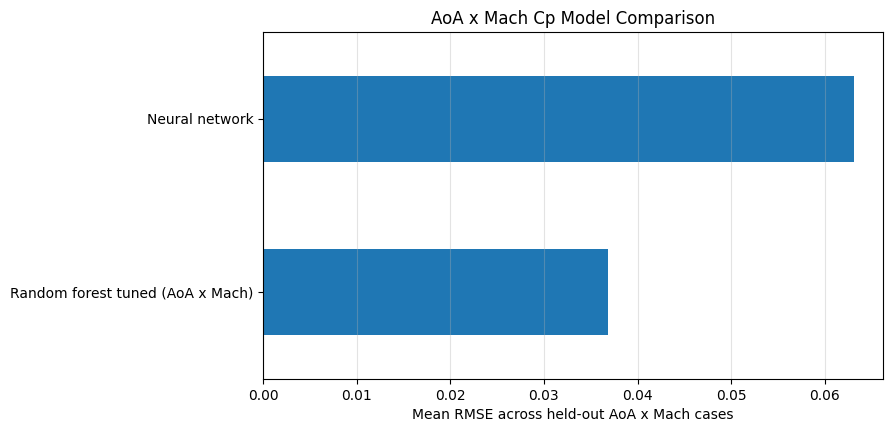

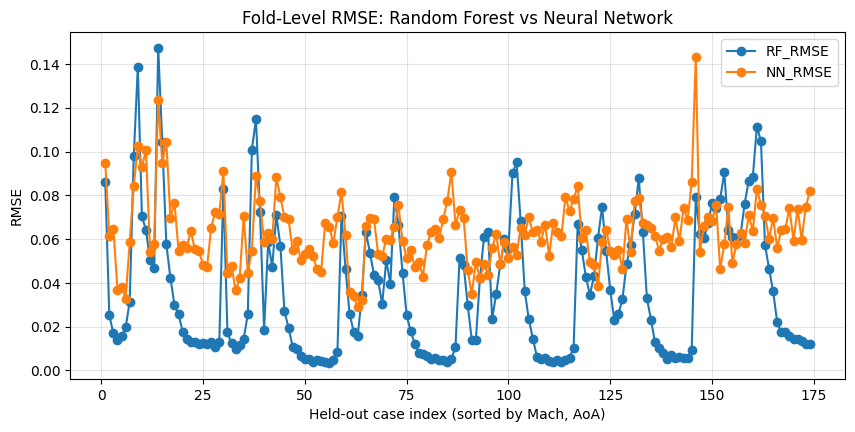

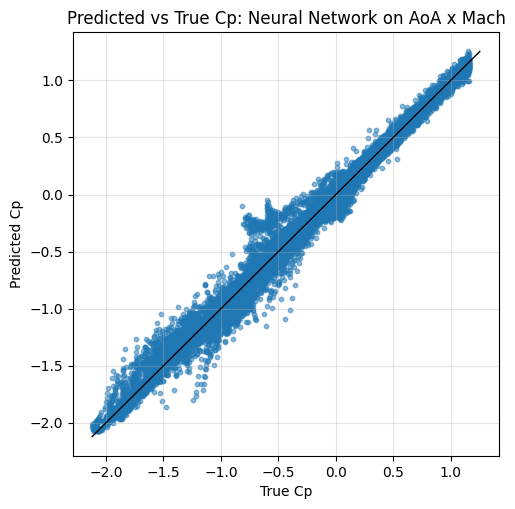

In [14]:
ax = comparison_summary["RMSE_mean"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 4.5),
)
ax.set_xlabel("Mean RMSE across held-out AoA x Mach cases")
ax.set_ylabel("")
ax.set_title("AoA x Mach Cp Model Comparison")
ax.grid(True, axis="x", alpha=0.35)
plt.show()

plot_df = rf_vs_nn_by_case.sort_values(["Freestream_Mach", "AoA"]).reset_index(drop=True)
plot_df["case_number"] = range(1, len(plot_df) + 1)

ax = plot_df.plot(
    x="case_number",
    y=["RF_RMSE", "NN_RMSE"],
    marker="o",
    figsize=(10, 4.5),
)
ax.set_xlabel("Held-out case index (sorted by Mach, AoA)")
ax.set_ylabel("RMSE")
ax.set_title("Fold-Level RMSE: Random Forest vs Neural Network")
ax.grid(True, alpha=0.35)
plt.show()

plt.figure(figsize=(5.5, 5.5))
plt.scatter(nn_predictions["y_true"], nn_predictions["y_pred"], s=10, alpha=0.5)
min_value = min(nn_predictions["y_true"].min(), nn_predictions["y_pred"].min())
max_value = max(nn_predictions["y_true"].max(), nn_predictions["y_pred"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="black", linewidth=1)
plt.xlabel("True Cp")
plt.ylabel("Predicted Cp")
plt.title("Predicted vs True Cp: Neural Network on AoA x Mach")
plt.grid(True, alpha=0.35)
plt.show()


## 9. Save AoA x Mach Metrics


In [15]:
nn_scores_path = METRICS_DIR / "cp_aoa_mach_nn_scores_by_case.csv"
nn_training_path = METRICS_DIR / "cp_aoa_mach_nn_training_by_case.csv"
comparison_summary_path = METRICS_DIR / "cp_aoa_mach_nn_comparison_summary.csv"
rf_vs_nn_path = METRICS_DIR / "cp_aoa_mach_nn_vs_random_forest_by_case.csv"
rf_vs_nn_summary_path = METRICS_DIR / "cp_aoa_mach_nn_vs_random_forest_summary.csv"

nn_scores.to_csv(nn_scores_path, index=False)
nn_training.to_csv(nn_training_path, index=False)
comparison_summary.reset_index().to_csv(comparison_summary_path, index=False)
rf_vs_nn_by_case.to_csv(rf_vs_nn_path, index=False)

winner = comparison_summary.index[0]
summary_row = {
    "dataset": "AoA x Mach",
    "rf_reference_model": rf_reference_name,
    "nn_rmse_mean": comparison_summary.loc["Neural network", "RMSE_mean"],
    "rf_rmse_mean": comparison_summary.loc[rf_reference_name, "RMSE_mean"],
    "winner": winner,
}
pd.DataFrame([summary_row]).to_csv(rf_vs_nn_summary_path, index=False)

print(nn_scores_path)
print(nn_training_path)
print(comparison_summary_path)
print(rf_vs_nn_path)
print(rf_vs_nn_summary_path)


/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_aoa_mach_nn_scores_by_case.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_aoa_mach_nn_training_by_case.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_aoa_mach_nn_comparison_summary.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_aoa_mach_nn_vs_random_forest_by_case.csv
/Users/pun/Desktop/CFD-ML/CFD-Machine-learning/reports/metrics/cp_aoa_mach_nn_vs_random_forest_summary.csv


## Conclusion

This notebook compares the AoA x Mach neural network against a tuned random-forest reference using Leave-One-Case-Out validation, where each fold is one full `(Freestream Mach, AoA)` CFD case.

If the neural network wins here, that is stronger evidence than the AoA-only result because it must generalize across both operating-condition dimensions at once.
